<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/Income_Analysis-Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Bunderson - Written Report Ch 9

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex0923)

,Subject,Gender,AFQT,Educ,Income2005
,<int>,<fct>,<dbl>,<int>,<int>
1,2,female,6.841,12,5500
2,6,male,99.393,16,65000
3,7,male,47.412,12,19000
4,8,female,44.022,14,36000
5,9,male,59.683,14,65000
6,13,male,72.313,16,8000


#Introduction
This analysis uses data from the National Longitudinal Study of Youth to examine whether males earn more than females after accounting for education and cognitive ability. The dataset includes annual income in 2005, AFQT scores (a measure of intelligence), and years of education for individuals who were employed in 2005.

Because both education and AFQT scores can affect income, this study compares males and females with similar values of these variables. The goal is to determine whether there is evidence that males have a higher mean salary than females when holding education and AFQT constant, and to estimate the size of any difference.

#Graphical Analysis

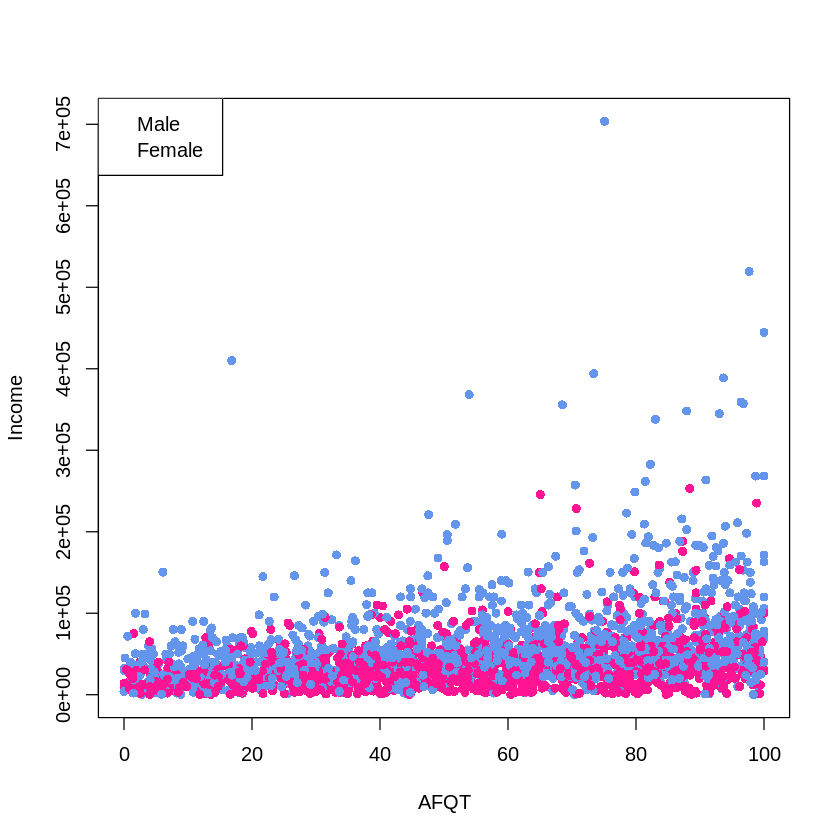

In [ ]:
plot(ex0923$AFQT, ex0923$Income2005, col = ifelse(ex0923$Gender=="male","cornflowerblue","deeppink"),
    pch = 16, xlab = "AFQT", ylab = "Income")
legend("topleft", c("Male", "Female"), col = c("blue", "deeppink"))

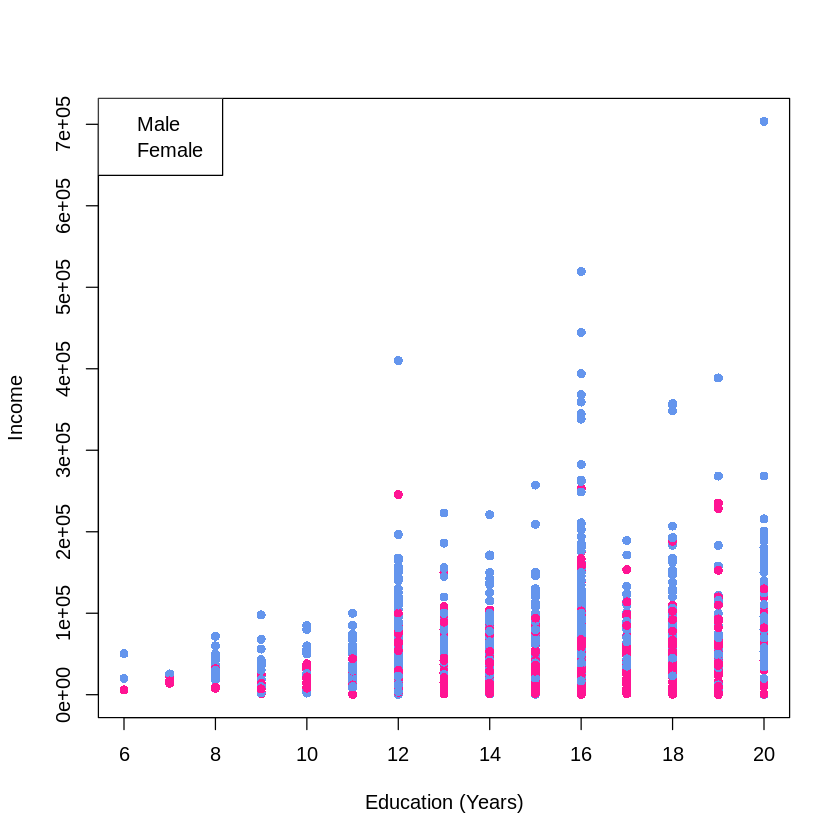

In [ ]:
plot(ex0923$Educ, ex0923$Income2005, col = ifelse(ex0923$Gender=="male","cornflowerblue","deeppink"),
    pch = 16, xlab = "Education (Years)", ylab = "Income")
legend("topleft", c("Male", "Female"), col = c("blue", "deeppink"))

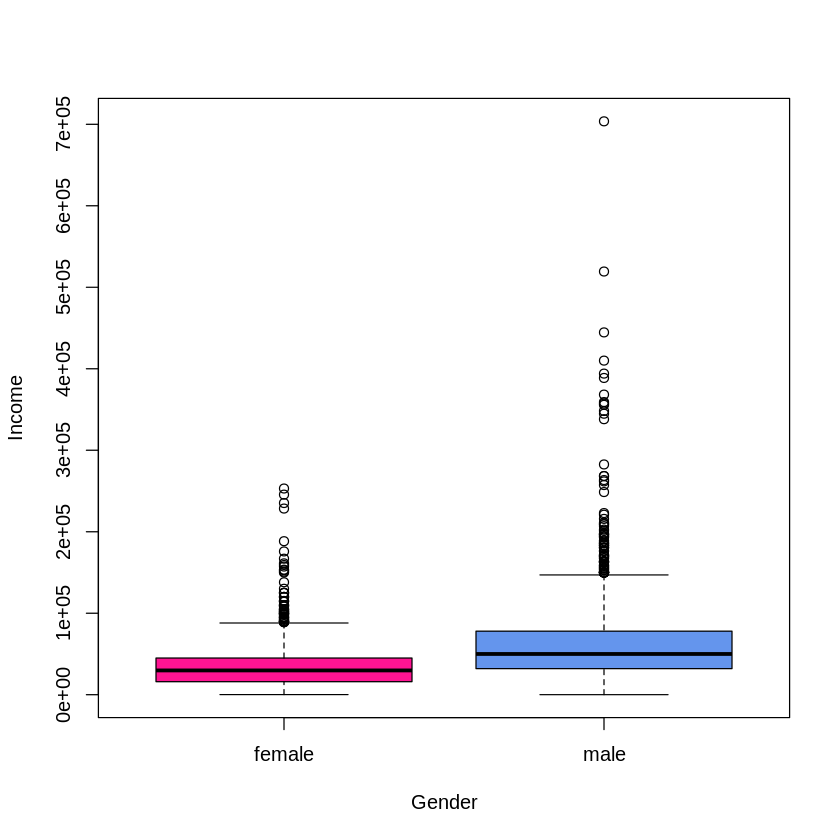

In [ ]:
boxplot(Income2005 ~ Gender, data = ex0923, col=c("deeppink","cornflowerblue"), ylab = "Income")

The scatterplots suggest that income tends to increase as education and AFQT increase, although the relationship is somewhat variable. The boxplot also suggests that male incomes may be somewhat higher than female incomes overall. However, because education and AFQT may confound the relationship between gender and income, a multiple linear regression model should be used to compare males and females after adjusting for these variables.

In [ ]:
myLM <- lm(Income2005 ~ Educ + AFQT + Gender, data=ex0923)

#Assumptions
##Independent
The independence assumption is met because each observation in the dataset represents a different individual from the National Longitudinal Study of Youth. Since the incomes, education levels, and AFQT scores are collected from separate people, there is no reason to expect that one individual’s outcome would influence another’s. Therefore, the observations can reasonably be treated as independent.

##Normality of Residuals


	Shapiro-Wilk normality test

data:  myLM$residuals
W = 0.74656, p-value < 2.2e-16


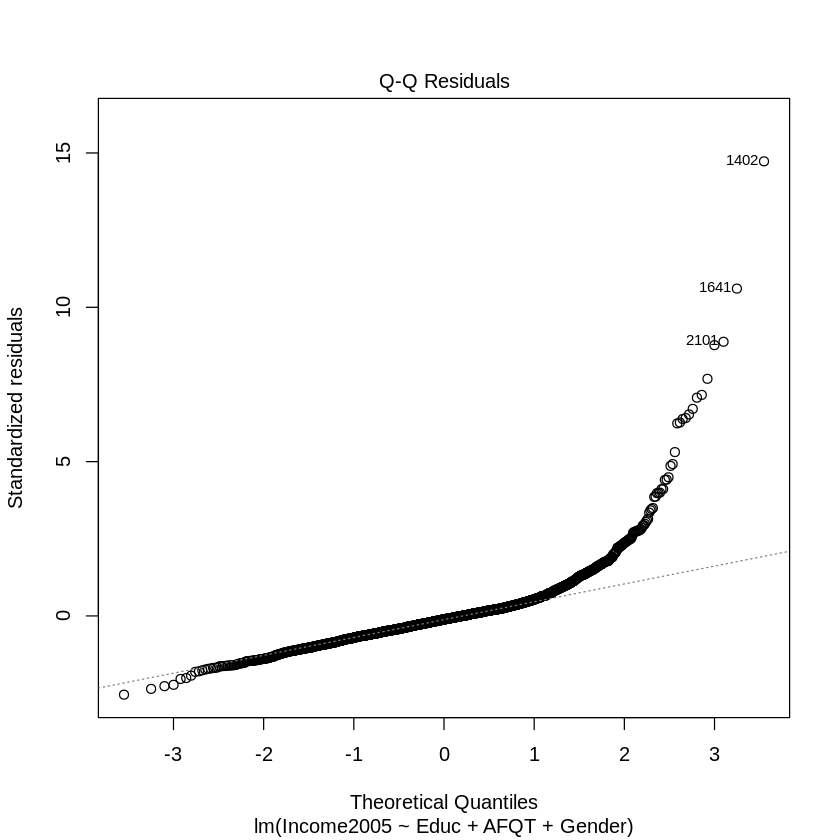

In [ ]:
plot(myLM,which=2)
shapiro.test(myLM$residuals)

##Constant Variance

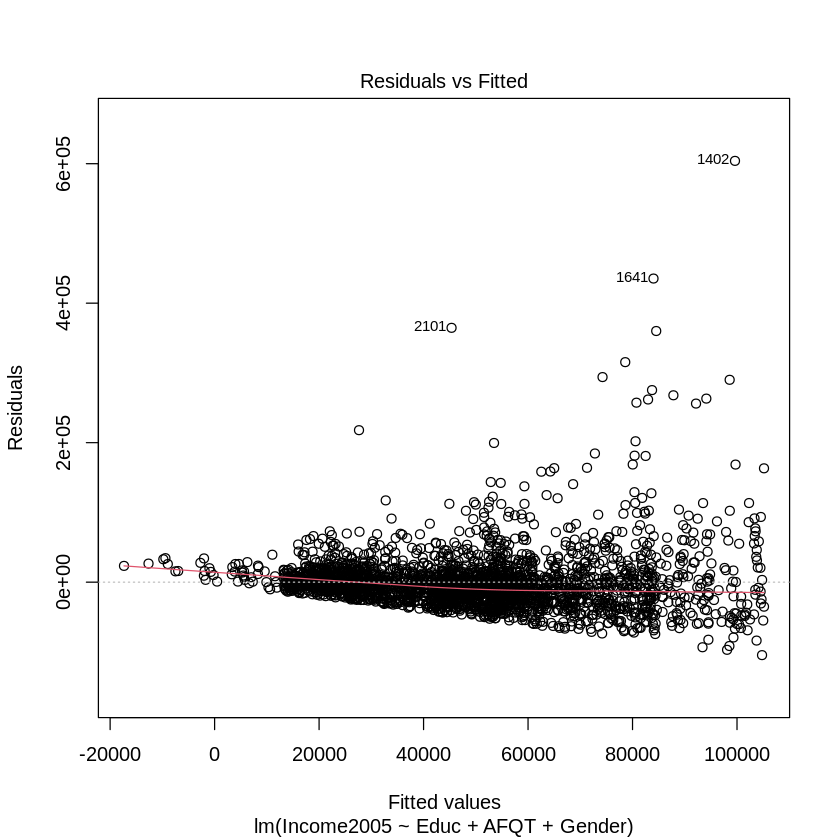

In [ ]:
plot(myLM, which=1)

A multiple linear regression model was first fit using income as the response and education, AFQT, and gender as predictors. Diagnostic plots from this model showed strong right-skewness in the residuals and a funnel shape in the residuals versus fitted plot, indicating violations of the normality and constant variance assumptions.

To address these issues,  we will log-transform income and refit the model using log income as the response.

In [ ]:
log_Income = log(ex0923$Income2005)

In [ ]:
log_Response <- lm(log_Income ~ Educ + AFQT + Gender, data=ex0923)

##Normality of Logging Response Plot


	Shapiro-Wilk normality test

data:  log_Response$residuals
W = 0.88506, p-value < 2.2e-16


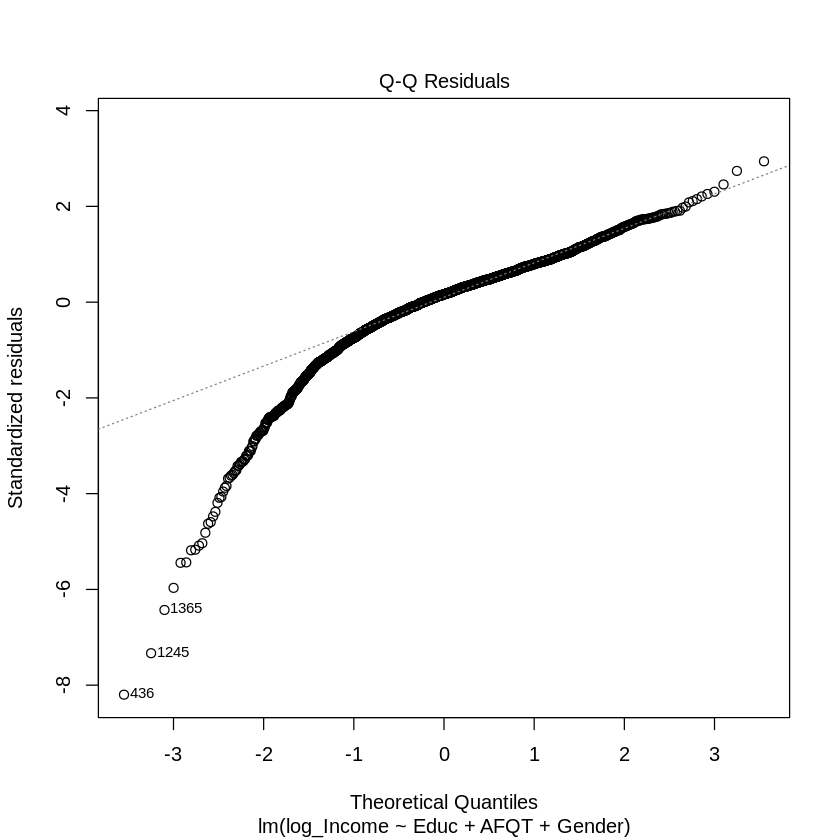

In [ ]:
plot(log_Response,which=2)
shapiro.test(log_Response$residuals)

##Constant Variance

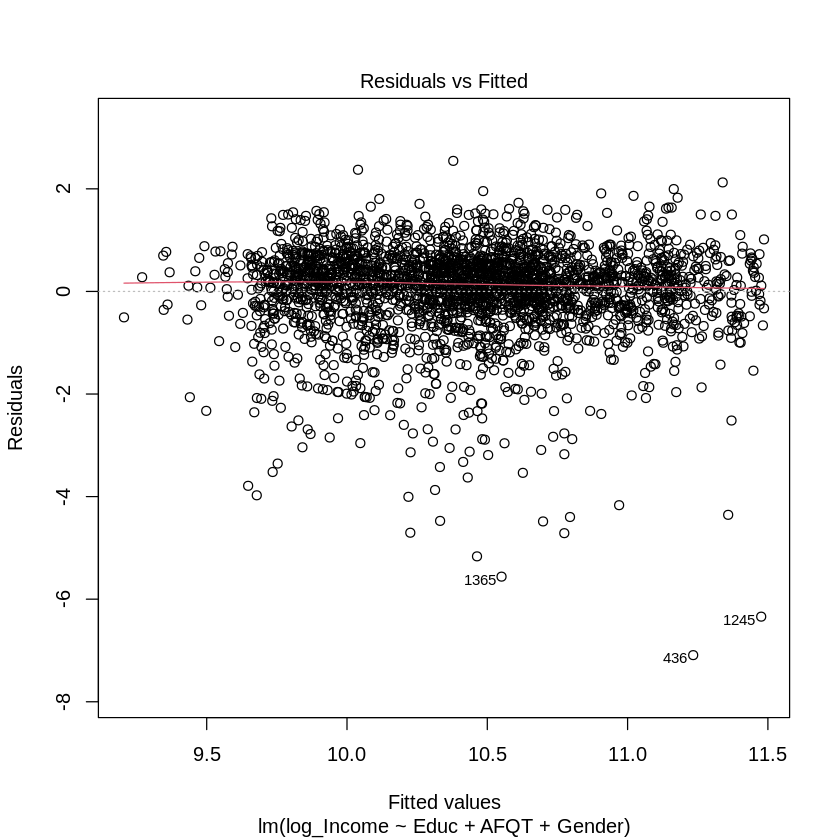

In [ ]:
plot(log_Response, which=1)

After this transformation, the residuals versus fitted plot showed a much more even spread, suggesting that the constant variance assumption is reasonably satisfied. The Q-Q plot of residuals also showed substantial improvement, with points following a straight line more closely. There is still heavy deviation remaining in the tails.

From my research, the large sample size means these deviations are not considered severe.

#Statistical Conclusion

In [ ]:
summary(log_Response)
confint(log_Response)


Call:
lm(formula = log_Income ~ Educ + AFQT + Gender, data = ex0923)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.0906 -0.3301  0.1404  0.5091  2.5452 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 8.7312115  0.1026287  85.076  < 2e-16 ***
Educ        0.0769506  0.0084888   9.065  < 2e-16 ***
AFQT        0.0059139  0.0007657   7.724  1.6e-14 ***
Gendermale  0.6245093  0.0341748  18.274  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8661 on 2580 degrees of freedom
Multiple R-squared:  0.2101,	Adjusted R-squared:  0.2092 
F-statistic: 228.7 on 3 and 2580 DF,  p-value: < 2.2e-16


,2.5 %,97.5 %
(Intercept),8.529968655,8.932454398
Educ,0.060305047,0.093596160
AFQT,0.004412575,0.007415313
Gendermale,0.557496441,0.691522169


All predictors are statistically significant, as their confidence intervals do not include zero.

In [ ]:
exp(coef(log_Response))
exp(confint(log_Response))

(Intercept)        Educ        AFQT  Gendermale 
6193.226825    1.079989    1.005931    1.867329

,2.5 %,97.5 %
(Intercept),5064.287091,7573.831779
Educ,1.062161,1.098116
AFQT,1.004422,1.007443
Gendermale,1.746295,1.996753


All estimated coefficients are positive, indicating that higher values of these predictors are associated with higher income, after adjusting for the other variables in the model.

Because the response variable is log-transformed, the coefficients are interpreted in terms of percent changes. After adjusting for education and AFQT, each additional year of education is associated with an approximate increase in income of between 6% and 10%. Similarly, higher AFQT scores are associated with a smaller but positive increase in income of approximately 0.4% to 0.7% per unit increase.

Most importantly, the coefficient for gender indicates that males earn substantially more than females after controlling for education and AFQT. Specifically, males are estimated to earn approximately 75% to 99.7% more than females on average, holding education and AFQT constant. This provides strong statistical evidence that mean income differs by gender even after adjusting for these factors.

#Scope of Inference
The data come from the National Longitudinal Study of Youth, which is an observational study rather than a designed experiment. Because individuals were not randomly assigned to different levels of education, AFQT scores, or gender, this analysis can identify associations but cannot establish causation. The results therefore describe a relationship between gender and income after adjusting for education and cognitive ability, rather than proving that gender causes differences in income.

The sample consists of individuals who were part of the original survey, were re-interviewed in 2006, and had paying jobs in 2005. As a result, the conclusions are most appropriately generalized to similar individuals in the U.S. workforce with comparable characteristics, rather than to all populations.

Given the relatively large sample size and the consistency of the statistical results, the evidence can be considered reasonably convincing that a difference in mean income exists between males and females after accounting for education and AFQT. However, because the data are observational and other unmeasured factors may influence income, the conclusions should be interpreted with some caution.